# Lab 4, Day 1 — Regression on California Housing

Build an MLP regressor in PyTorch, then compare it head-to-head against your own Lab 2
NumPy gradient descent code on the exact same data. See `Lab4_Day1_Instructions.md`
for the full walkthrough.

This notebook is just a shell: it gives you a place to call and plot your functions,
but the loading, model, training loop, and comparison are yours to write.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


## Step 1: Load and preprocess (`stage_a_regression.py`)

In [10]:
# TODO: load California Housing, split train/test, fit_transform the scaler on
# train only, transform test, reshape targets to (n, 1)

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


torch.manual_seed(0)
np.random.seed(0)

data =  fetch_california_housing()

X_train , X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)  


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)


## Step 2-3: Model, loss, optimizer, training loop

In [11]:
# TODO: build_mlp from train.py (or write it directly), train with train_full_batch,
# store loss.item() each epoch - not the tensor itself
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, out_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.network(x)

In [12]:
input_size = X_train.shape[1]
hidden_size = 32
out_dim = 1

model = MLP(input_size, hidden_size, out_dim)

In [13]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [14]:
train_losses = []

for epoch in range(100):
    predictions = model(X_train)
    loss = criterion(predictions, y_train)

    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())


# Save the model
torch.save(model.state_dict(), "stage_a.pt")




## Step 4: Evaluate and plot

Test MSE: 0.4594


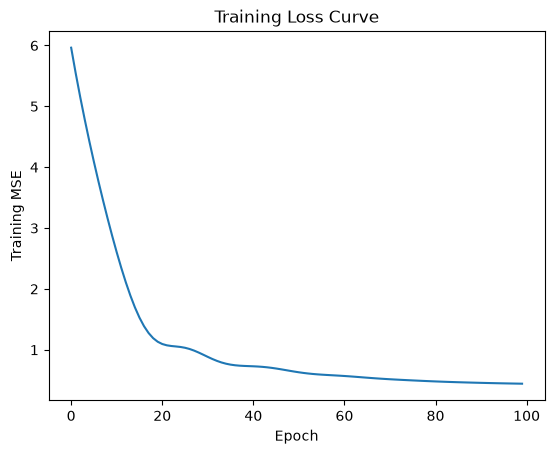

In [15]:
# TODO: model.eval() + torch.no_grad() to get test MSE; plot the training loss curve

# Test MSE
model.eval()

with torch.no_grad():
    predictions = model(X_test)
    test_mse = criterion(predictions, y_test)

print(f"Test MSE: {test_mse.item():.4f}")


# Plot training loss curve
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Training Loss Curve")
plt.show()


In [16]:
model.load_state_dict(torch.load("stage_a.pt", weights_only=True))
model.eval()

with torch.no_grad():
    prediction = model(X_test[0].unsqueeze(0))

print("Prediction:", prediction.item())
print("Actual:", y_test[0].item())

Prediction: 0.5397352576255798
Actual: 0.47699999809265137


## Step 5: Compare against your Lab 2 NumPy code

In [17]:
# TODO: fit a linear model on the same preprocessed data using your own hand-derived
# gradient descent, compare test MSE against the MLP, plot both curves side by side

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)
linear_mse = criterion(torch.tensor(linear_predictions), y_test)
print(f"Linear Model Test MSE: {linear_mse.item():.4f}")


Linear Model Test MSE: 0.5559


MLP Test MSE: 0.4594
Linear Model Test MSE: 0.5546


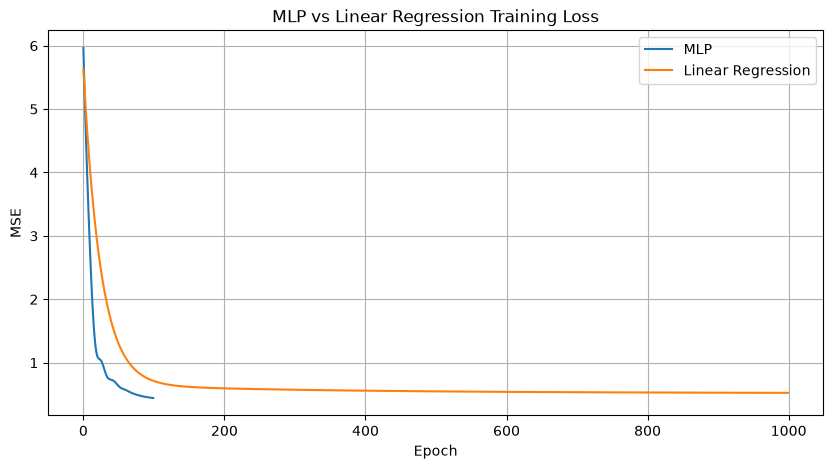

In [18]:
# Step 5: Compare MLP against a linear model trained using
# hand-derived NumPy gradient descent

# Convert PyTorch tensors back to NumPy
X_train_np = X_train.numpy()
X_test_np = X_test.numpy()
y_train_np = y_train.numpy().reshape(-1)
y_test_np = y_test.numpy().reshape(-1)

# Add bias column
X_train_bias = np.c_[np.ones(X_train_np.shape[0]), X_train_np]
X_test_bias = np.c_[np.ones(X_test_np.shape[0]), X_test_np]

# Initialize weights
weights = np.zeros(X_train_bias.shape[1])

learning_rate = 0.01
epochs = 1000

linear_losses = []

# Hand-derived gradient descent
for epoch in range(epochs):
    # Predictions
    predictions = X_train_bias @ weights

    # Error
    error = predictions - y_train_np

    # Mean squared error
    loss = np.mean(error ** 2)
    linear_losses.append(loss)

    # Gradient of MSE
    gradient = (2 / len(X_train_bias)) * (X_train_bias.T @ error)

    # Update weights
    weights -= learning_rate * gradient


# Test predictions
linear_predictions = X_test_bias @ weights

# Test MSE
linear_test_mse = np.mean((linear_predictions - y_test_np) ** 2)

print(f"MLP Test MSE: {test_mse.item():.4f}")
print(f"Linear Model Test MSE: {linear_test_mse:.4f}")


# Plot both training curves
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="MLP")
plt.plot(linear_losses, label="Linear Regression")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("MLP vs Linear Regression Training Loss")
plt.legend()
plt.grid(True)
plt.show()

### Written prompt

> **Your MLP barely beats the linear model, and might lose to it. What would have to be
> true about this data for the MLP to win decisively — and what does that tell you about
> when a neural network is the right tool?**



The MLP would win decisively if the California Housing data contained strong nonlinear relationships and complex interactions between features that a linear model could not capture. For example, if combinations of location, income, housing age, and occupancy affected house prices in nonlinear ways, the neural network could learn these patterns. If the relationships are mostly linear, however, a simple linear model may perform just as well or better. This shows that neural networks are most useful when the data contains complex nonlinear patterns and enough data is available to learn them; for simpler relationships, traditional models can be more efficient and easier to interpret.


---
**Before you close this notebook today:** save your trained model
(`torch.save(model.state_dict(), "stage_a.pt")`), and run the Fashion-MNIST loader
once (see `Lab4_Day2_Instructions.md` Step 1) so it's cached before Day 2. Keep this
notebook - Day 2 is a new notebook in the same folder.